In [1]:
import pandas as pd

In [20]:
# Cargar csv con las features procesadas
df = pd.read_csv ('historico_partidos.csv', parse_dates=['date'])


In [21]:
#Esto no estará en el final. Vendría así del EDA
#Copiar las probabilidades
wta = pd.read_csv ('wta_copia_mod.csv') 
# Añadir las probabilidades de la casa de apuestas al histórico usando match_id como clave
df['odd_1'] = df['match_id'].map(wta['prob_1'])
df['odd_2'] = df['match_id'].map(wta['prob_2'])
df['tournament_type'] = df ['match_id'].map(wta['tournament_type'])

In [22]:
#eliminar 2007
df = df [df['date'].dt.year != 2007]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41958 entries, 29 to 44348
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   match_id             41958 non-null  int64         
 1   date                 41958 non-null  datetime64[ns]
 2   surface              41958 non-null  object        
 3   round                41958 non-null  object        
 4   rank_diff            41958 non-null  float64       
 5   wins2meses_p1        41958 non-null  float64       
 6   wins2meses_p2        41958 non-null  float64       
 7   ratio_superficie_p1  41958 non-null  float64       
 8   ratio_superficie_p2  41958 non-null  float64       
 9   h2h                  41958 non-null  float64       
 10  ratio_ronda_p1       41958 non-null  float64       
 11  ratio_ronda_p2       41958 non-null  float64       
 12  experiencia_p1       41958 non-null  int64         
 13  experiencia_p2       41958 non-null

In [7]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Profiling Report")
profile.to_file("historico_report.html")

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_18928\3127686900.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 37.42it/s]


In [ ]:
# Revisando el profile: Tratamiento de valores negativos en apuestas.

In [24]:
# Train y test. Puesto que el modelo sólo puede aprender hacia atrás la división no
# puede ser aleatoria. Me voy a guardar 2025 (en adelante) para entrenar

corte = '2025-01-01'
df_train = df[df['date'] < corte].copy()
df_test  = df[df['date'] >= corte].copy()

print(f'Train: {len(df_train)} partidos')
print(f'Test:  {len(df_test)} partidos')
print(f'%:  {len(df_test)/len(df_train)} partidos')


Train: 38755 partidos
Test:  3203 partidos
%:  0.08264740033544059 partidos


In [25]:
# Análisis de variables creadas
# Target muy balanceado.
# h2h tiene muchos ceros. No parece que vaya a ser muy relevante
# is_new tampoco parece que vaya a aportar mucho
# Outliers: en diferencia de ranking hay valores por encima de 1800 que son. Es muy excepcional y puede alterar
# el modelo. Por encima del ranking 500 o algo así es super inusual. Voy a capar por los extremos para igualar
# a los máximos sin tener en cuenta outliers

# Evitamos data lekeage. Calcula el límite mirando SOLO train
# Hay tanto outliers positivos como negativos claro. Capamos por los dos
limite_superior =  df_train['rank_diff'].quantile(0.99)
limite_inferior =  df_train['rank_diff'].quantile(0.01)

# Aplicamos la misma transformación a ambos
df_train['rank_diff'] = df_train['rank_diff'].clip(lower=limite_inferior, upper=limite_superior)
df_test['rank_diff']  = df_test['rank_diff'].clip(lower=limite_inferior, upper=limite_superior)

In [30]:
df_train.describe()

,match_id,date,rank_diff,wins2meses_p1,wins2meses_p2,ratio_superficie_p1,ratio_superficie_p2,h2h,ratio_ronda_p1,ratio_ronda_p2,experiencia_p1,experiencia_p2,target,is_new_p1,is_new_p2
count,41146.000000,41146,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000,41146.000000
mean,20572.506951,2015-10-13 15:43:19.076459264,1.392383,0.499132,0.499835,0.506584,0.506717,0.499356,0.496175,0.495460,151.997861,151.781899,1.499976,0.094153,0.092500
min,0.000000,2006-12-31 00:00:00,-367.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,10286.250000,2011-04-30 00:00:00,-40.000000,0.333333,0.333333,0.400000,0.400000,0.500000,0.400000,0.400000,37.250000,38.000000,1.000000,0.000000,0.000000
50%,20572.500000,2015-08-21 00:00:00,1.000000,0.545455,0.545455,0.500000,0.500000,0.500000,0.500000,0.500000,105.000000,106.000000,1.000000,0.000000,0.000000
75%,30858.750000,2020-01-14 00:00:00,41.000000,0.700000,0.700000,0.615385,0.615385,0.500000,0.621573,0.622222,224.000000,223.000000,2.000000,0.000000,0.000000
max,41158.000000,2024-12-31 00:00:00,395.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,827.000000,824.000000,2.000000,1.000000,1.000000
std,11877.983461,NaN,97.764510,0.290252,0.290805,0.175755,0.176092,0.270783,0.207791,0.207258,147.097733,146.026211,0.500006,0.292044,0.289734


In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest # basado en p-values
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer

In [54]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost

In [28]:
df_train.columns

Index(['match_id', 'date', 'surface', 'round', 'rank_diff', 'wins2meses_p1',
       'wins2meses_p2', 'ratio_superficie_p1', 'ratio_superficie_p2', 'h2h',
       'ratio_ronda_p1', 'ratio_ronda_p2', 'experiencia_p1', 'experiencia_p2',
       'target', 'is_new_p1', 'is_new_p2', 'odd_1', 'odd_2',
       'tournament_type'],
      dtype='object')

In [29]:
X_train = df_train.drop(columns= ['match_id', 'date', 'target', 'odd_1', 'odd_2'])
X_test = df_test.drop (columns= ['match_id', 'date', 'target', 'odd_1', 'odd_2'])
y_train = df_train ['target']
y_test = df_test ['target']

In [30]:
# Convertir los target a O y 1 en vez de 1 y 2. Algunos modelos se confunden
y_train = (y_train == 1).astype(int)
y_test  = (y_test == 1).astype(int)

In [41]:
# Probar Random Forest y XGBoost para empezar

# Definir  columnas categóricas y columnas numéricas
cat_cols = ['surface', 'round', 'tournament_type']
num_cols = [c for c in X_train.columns if c not in cat_cols]
# Preprocesador
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe = Pipeline (steps=[("preprocessor", preprocessor), #usa este por defecto si no pongo ninguno en los parámetros
    ('classifier', RandomForestClassifier())
])
#Los parámetros para Random Forest
random_forest_params = {
    'classifier': [RandomForestClassifier()],
    'classifier__max_depth': [2,3,5],
    'classifier__n_estimators': [100, 200]
}

random_best = GridSearchCV(estimator = pipe,
                  param_grid = random_forest_params,
                  cv = 5,
                  n_jobs=-1)

random_best.fit (X_train, y_train)

print(random_best.best_score_)
print(random_best.best_params_)



0.6599664559411689
{'classifier': RandomForestClassifier(), 'classifier__max_depth': 5, 'classifier__n_estimators': 100}


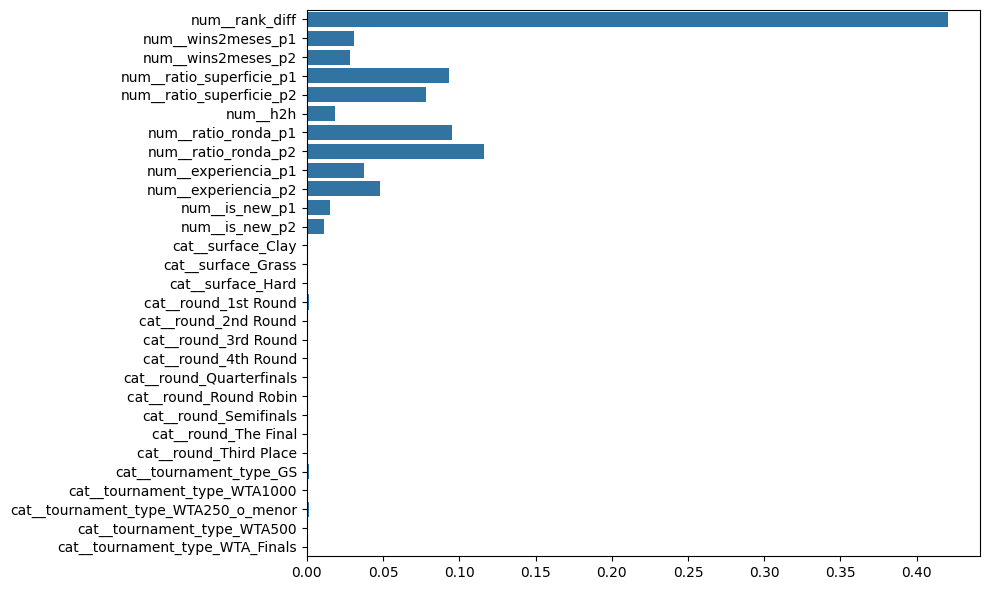

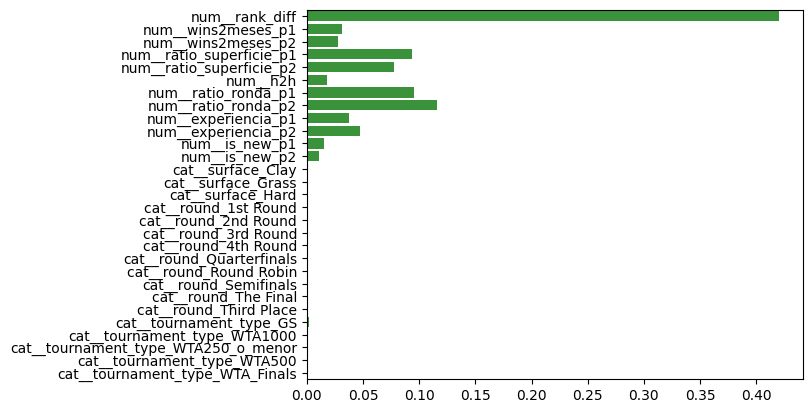

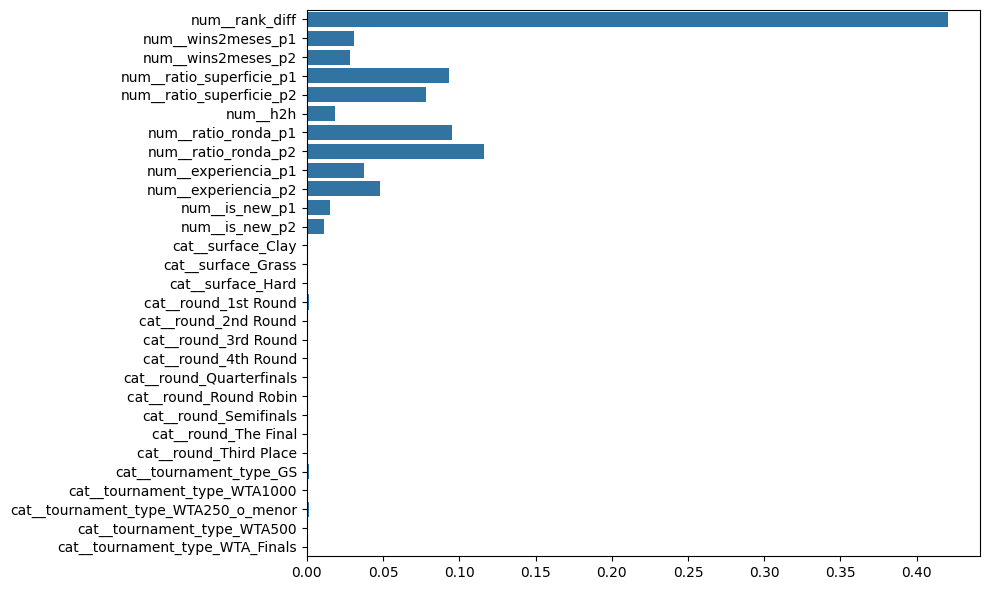

In [ ]:
import seaborn as sns
%matplotlib inline
# Nombres de las features
classes = random_best.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

# Importancias
importancias = random_best.best_estimator_.named_steps['classifier'].feature_importances_

# Plot
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=importancias, y=classes, ax=ax)
display(fig)

In [35]:
# METRICAS
# Accuracy
y_pred = random_best.predict (X_test)
acc_modelo = accuracy_score(y_test, y_pred)
print(f'Modelo:          {acc_modelo:.2%}')

#Casas de apuestas
# 1 - Accuracy de las casas en el mismo período de test
odds_1 = df.loc[df_test['match_id'], 'odd_1'].values
odds_2 = df.loc[df_test['match_id'], 'odd_2'].values
# Si odd_1 < odd_2 → P1 es favorita → las casas predicen que gana P1 → 1
# Si odd_1 > odd_2 → P2 es favorita → las casas predicen que gana P2 → 0
pred_casas = (odds_1 > odds_2).astype(int)
print(f'Accuracy casas: {accuracy_score(y_test, pred_casas):.2%}')

# 2 - Baseline tonto: predecir siempre que gana el mejor ranking
pred_ranking = (df_test['rank_diff'] < 0).astype(int)
print(f'Accuracy solo ranking: {accuracy_score(y_test, pred_ranking):.2%}')

Modelo:          63.38%
Accuracy casas: 68.59%
Accuracy solo ranking: 62.78%


In [ ]:
y=random_best.feature

In [38]:
# A ver qué tal da xgb


# Pipeline para xgb
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgboost.XGBClassifier(eval_metric='logloss'))  # valor por defecto
])

xgb_params = {
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
}

xgb_best = GridSearchCV(estimator = pipe_xgb,
                  param_grid = xgb_params,
                  cv = 5,
                  n_jobs=-1)

xgb_best.fit (X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200, ...], 'classifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [39]:
print(xgb_best.best_score_)
print(xgb_best.best_params_)

0.6633466649464584
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


In [40]:
# METRICAS
# Accuracy
y_pred = xgb_best.predict (X_test)
acc_modelo_xgb = accuracy_score(y_test, y_pred)
print(f'Modelo:          {acc_modelo_xgb:.2%}')
print(f'Accuracy casas: {accuracy_score(y_test, pred_casas):.2%}')
print(f'Accuracy solo ranking: {accuracy_score(y_test, pred_ranking):.2%}')

Modelo:          65.13%
Accuracy casas: 68.59%
Accuracy solo ranking: 62.78%


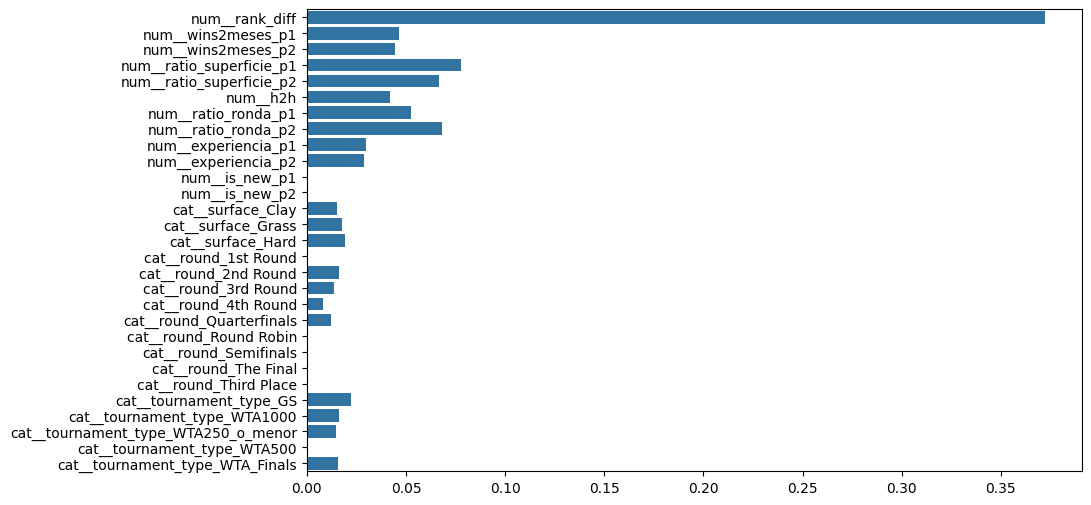

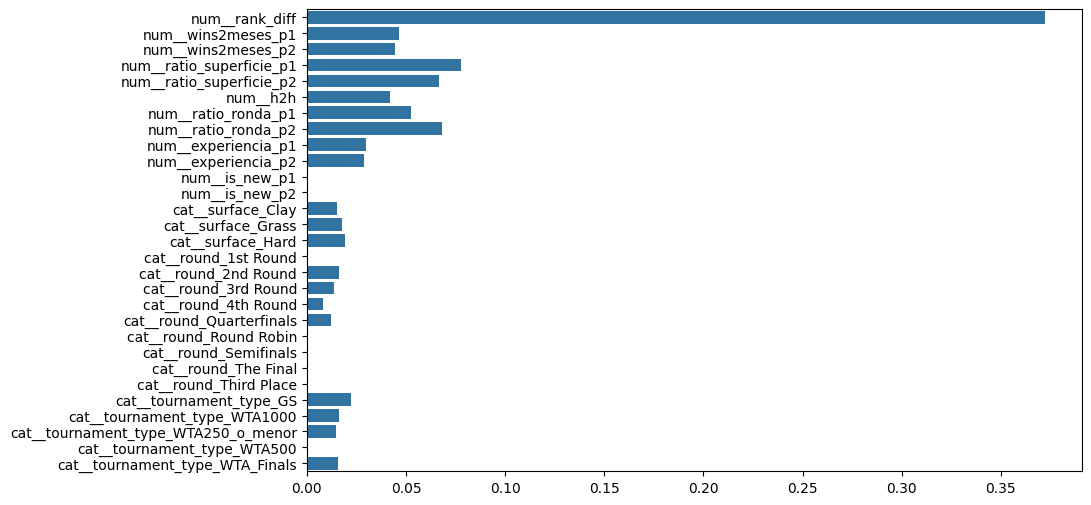

In [48]:
%matplotlib inline
# Nombres de las features
classes = xgb_best.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

# Importancias
importancias = xgb_best.best_estimator_.named_steps['classifier'].feature_importances_

# Plot
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=importancias, y=classes, ax=ax)
display(fig)

In [ ]:
# Antes de seguir voy a crearme una función para ir llevando registro de lo que pruebo y sus métricas

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# Crear el dataframe vacío
resultados = pd.DataFrame(columns=[
    'modelo',
    'parametros', 
    'accuracy_modelo',
    'accuracy_casas',
    'accuracy_ranking',
    'correlacion_casas'
])

# Función para evaluar y añadir una fila
def evaluar_modelo(nombre, modelo_fit, X_test, y_test, df_test, df):
    
    # Predicciones
    y_pred = modelo_fit.predict(X_test)
    y_proba = modelo_fit.predict_proba(X_test)[:, 1]
    
    # Accuracy del modelo
    acc_modelo = accuracy_score(y_test, y_pred)
    
    # Accuracy casas
    prob_1 = df.loc[df_test['match_id'], 'odd_1'].values
    prob_2 = df.loc[df_test['match_id'], 'odd_2'].values
    mask_validas = ~np.isnan(prob_1) & ~np.isnan(prob_2) # había algun nulo en las apuestas. ignorar
    pred_casas = (prob_1[mask_validas] > prob_2[mask_validas]).astype(int)
    acc_casas = accuracy_score(y_test[mask_validas], pred_casas)
    
    # Accuracy solo ranking
    pred_ranking = (df_test['rank_diff'] < 0).astype(int)
    acc_ranking = accuracy_score(y_test, pred_ranking)
    
    # Correlación con casas
    correlacion = np.corrcoef(y_proba[mask_validas], prob_1[mask_validas])[0,1]
    
    # Parámetros del mejor modelo si es GridSearch
    try:
        params = modelo_fit.best_params_
    except:
        params = {}
    
    # Añadir fila
    nueva_fila = {
        'modelo': nombre,
        'parametros': str(params),
        'accuracy_modelo': round(acc_modelo, 4),
        'accuracy_casas': round(acc_casas, 4),
        'accuracy_ranking': round(acc_ranking, 4),
        'correlacion_casas': round(correlacion, 4)
    }
    
    return pd.concat([resultados, pd.DataFrame([nueva_fila])], ignore_index=True)

In [52]:
resultados = evaluar_modelo('Random Forest', random_best, X_test, y_test, df_test, df)
resultados = evaluar_modelo('XGBoost', xgb_best, X_test, y_test, df_test, df)

C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_18928\981369977.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([resultados, pd.DataFrame([nueva_fila])], ignore_index=True)


In [53]:
resultados

,modelo,parametros,accuracy_modelo,accuracy_casas,accuracy_ranking,correlacion_casas
0,Random Forest,"{'classifier': RandomForestClassifier(), 'clas...",0.6322,0.6861,0.6278,0.8367
1,XGBoost,"{'classifier__learning_rate': 0.05, 'classifie...",0.6513,0.6861,0.6278,0.8556


In [55]:
# Pipeline para GradientBoost
# Un poco a la desesperada
pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())  
])

gb_params = {
    'classifier__max_depth': [3, 4, 5],
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.5],
    'classifier__subsample': [0.8, 1.0],
}

gb_best = GridSearchCV(estimator = pipe_gb,
                  param_grid = gb_params,
                  cv = 5,
                  n_jobs=-1)

gb_best.fit (X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.5], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200], 'classifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [56]:
resultados = evaluar_modelo('GradientBoost', gb_best, X_test, y_test, df_test, df)

In [57]:
resultados

,modelo,parametros,accuracy_modelo,accuracy_casas,accuracy_ranking,correlacion_casas
0,Random Forest,"{'classifier': RandomForestClassifier(), 'clas...",0.6322,0.6861,0.6278,0.8367
1,XGBoost,"{'classifier__learning_rate': 0.05, 'classifie...",0.6513,0.6861,0.6278,0.8556
2,GradientBoost,"{'classifier__learning_rate': 0.05, 'classifie...",0.6469,0.6861,0.6278,0.8531


In [61]:
X_train.columns

Index(['surface', 'round', 'rank_diff', 'wins2meses_p1', 'wins2meses_p2',
       'ratio_superficie_p1', 'ratio_superficie_p2', 'h2h', 'ratio_ronda_p1',
       'ratio_ronda_p2', 'experiencia_p1', 'experiencia_p2', 'is_new_p1',
       'is_new_p2', 'tournament_type'],
      dtype='object')

In [62]:
# XGboost no usa is new. Tampoco usa otras de rondas y tal pero como son muy aleatorias (sí usa semifinales pero
# no final las voy a dejar por ahora)

X_train_red = X_train.drop(columns=['is_new_p1', 'is_new_p2'])
X_test_red  = X_test.drop(columns=['is_new_p1', 'is_new_p2'])

cat_cols = ['surface', 'round', 'tournament_type']
num_cols_red = [c for c in X_train_red.columns if c not in cat_cols]

preprocessor_red = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_red),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe_xgb_red = Pipeline(steps=[
    ('preprocessor', preprocessor_red),
    ('classifier', xgboost.XGBClassifier(eval_metric='logloss'))
])

xgb_red_best = GridSearchCV(
    estimator=pipe_xgb_red,
    param_grid=xgb_params,
    cv=5,
    n_jobs=-1
)

xgb_red_best.fit(X_train_red, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200, ...], 'classifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [63]:
resultados = evaluar_modelo('XGBoost_Red', xgb_red_best, X_test_red, y_test, df_test, df)

In [64]:
resultados

,modelo,parametros,accuracy_modelo,accuracy_casas,accuracy_ranking,correlacion_casas
0,Random Forest,"{'classifier': RandomForestClassifier(), 'clas...",0.6322,0.6861,0.6278,0.8367
1,XGBoost,"{'classifier__learning_rate': 0.05, 'classifie...",0.6513,0.6861,0.6278,0.8556
2,GradientBoost,"{'classifier__learning_rate': 0.05, 'classifie...",0.6469,0.6861,0.6278,0.8531
3,XGBoost_Red,"{'classifier__learning_rate': 0.05, 'classifie...",0.6513,0.6861,0.6278,0.8556


In [65]:
import pickle

with open('gbx_red.model', "wb") as archivo_salida:
    pickle.dump(xgb_red_best.best_estimator_, archivo_salida)